# Getting started: the NiSpace object

This notebook introduces the core NiSpace API through a complete, step-by-step colocalization analysis. If you haven't already, have a look at the [Spatial Colocalization notebook](intro01_spatial_colocalizations.ipynb) for the conceptual background.

We'll use a NeuroQuery meta-analytic map for "pain" as our input and test whether it colocalizes with a set of PET-derived neurotransmitter receptor maps. This is a clean, self-contained example with a nice biological story.

In [2]:
# make progress bars render as text in the docs
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

## The input map: a NeuroQuery pain map

We need a brain map to start with. I downloaded a meta-analytic map from [NeuroQuery](https://neuroquery.org/query?text=pain) — a tool that generates brain activation maps from text queries against the neuroimaging literature. The map for "pain" is a z-score image reflecting how consistently the pain literature reports activation across brain regions.

Technically this is not a T-map from a single study, but it serves our purpose perfectly: it's a plausible spatial pattern of pain-related brain activity, and it lives in MNI space like all our reference data.

WARNING | 20/07/26 18:19:56 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

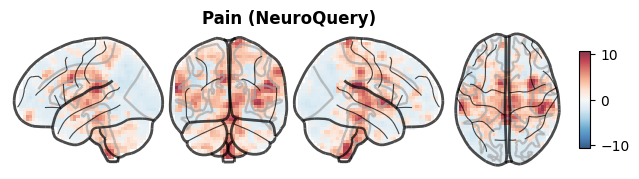

In [3]:
from nispace.io import load_img
from nispace.plotting import brainplot

# load the pain map
pain_map = load_img("neuroquery/pain.nii.gz")

# plot it
brainplot(pain_map, title="Pain (NeuroQuery)")

The map shows the expected pattern: activation in regions associated with pain processing, including the insula, anterior cingulate cortex, and somatosensory cortex.

## Reference data: PET receptor maps

For our reference maps, we'll use NiSpace's curated PET receptor dataset. This collection contains group-average receptor density maps for a wide range of neurotransmitter receptors and transporters, derived from PET studies in healthy subjects.

We fetch the data already parcellated into our target parcellation. This is much faster than loading the volumetric images and parcellating them on the fly — NiSpace ships pre-parcellated versions of all reference datasets.

Throughout this series we use **Yan200** as the default parcellation. Yan et al. (2023) introduced this as an updated, **homotopic** version of the widely used Schaefer parcellation: each left-hemisphere parcel has an exact right-hemisphere counterpart of the same shape, which plays nicely with the spin-based null model methods used in permutation testing. We use the 17-network Kong variant. See the [Parcellations](../parcellations.rst) page for more options.

In [4]:
from nispace.datasets import fetch_reference

# fetch the PET maps, pre-parcellated into Yan200
# collection="UniqueTracers" picks one representative tracer per receptor target
pet_maps = fetch_reference(
    "pet",
    parcellation="Yan200",
    collection="UniqueTracers",
    print_references=False  # suppress the long reference list for now
)

print(f"PET DataFrame: {pet_maps.shape[0]} maps x {pet_maps.shape[1]} parcels")
pet_maps.head(3)

INFO | 20/07/26 18:19:56 | nispace.datasets: Loading pet maps.


INFO | 20/07/26 18:19:56 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 20/07/26 18:19:56 | nispace.datasets: Filtering maps by collection.


INFO | 20/07/26 18:19:56 | nispace.datasets: Loading data parcellated with 'Yan200'


PET DataFrame: 29 maps x 200 parcels


hemi-L_div-DefaultC_lab-IPL  \
set     map                                                                               
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                     0.636817   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                     0.634173   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                     0.672142   

                                                            hemi-L_div-DefaultC_lab-PHC  \
set     map                                                                               
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                     0.540483   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                     0.438008   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                     0.540954   

                                                            hemi-L_div-DefaultB_lab-IPL+1  \
set     map                                                                                 
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                       0.682817   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                       0.611914   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                       0.680068   

                                                            hemi-L_div-DefaultB_lab-IPL+2  \
set     map                                                                                 
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                       0.728153   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                       0.624071   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                       0.686451   

                                                            hemi-L_div-DefaultB_lab-PFCd+1  \
set     map                                                                                  
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                        0.578478   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                        0.428779   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                        0.503211   

                                                            hemi-L_div-DefaultB_lab-PFCd+2  \
set     map                                                                                  
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                        0.529284   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                        0.431085   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                        0.541792   

                                                            hemi-L_div-DefaultB_lab-PFCl  \
set     map                                                                                
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                      0.693211   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                      0.541520   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                      0.565813   

                                                            hemi-L_div-DefaultB_lab-PFCm  \
set     map                                                                                
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                      0.665677   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...                      0.513382   
        target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016                      0.666088   

                                                            hemi-L_div-DefaultB_lab-PFCv+1  \
set     map                                                                                  
General target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castril...                        0.723623   
        target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith...            

The DataFrame has a two-level index: the first level is the neurotransmitter system ("set"), the second is the full tracer identifier. These sets are used later for X-Set Enrichment Analysis ([XSEA notebook](intro10_xsea.ipynb)) — for now we just treat the whole thing as a collection of maps.

## Initializing the NiSpace object

NiSpace follows an object-oriented design. We first create a `NiSpace` instance, passing all the data and configuration options. Processing happens later when we call the analysis methods.

The two central arguments are:
- `x`: the reference maps (here: PET receptor maps)
- `y`: the input map(s) we want to analyze (here: the pain map)

We also specify the parcellation, which tells NiSpace how to parcellate `y` (since it's a volumetric NIfTI image) and how to align it with `x` (which is already a parcellated DataFrame).

In [5]:
from nispace.api import NiSpace

nsp = NiSpace(
    x=pet_maps,        # reference maps
    y=pain_map,        # input map — will be parcellated automatically
    y_labels="Pain",   # a name for our input map
    parcellation="Yan200",
    n_proc=4,          # use 4 parallel processes where possible
    seed=42            # for reproducibility
)

print(nsp)

## Fitting: parcellation and data ingestion

Calling `fit()` is where actual data processing begins. For the pain map (a NIfTI image), this means parcellating it into the 200 Yan200 regions. For the PET maps (already a DataFrame), it validates and stores the data.

In [6]:
nsp.fit()

# inspect the parcellated pain map
print("Parcellated pain map:")
nsp.get_y()

INFO | 20/07/26 18:19:56 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 20/07/26 18:19:56 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 20/07/26 18:19:56 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 20/07/26 18:19:57 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 20/07/26 18:19:57 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


...

Parcellating (4 proc): 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 116.69it/s]

INFO | 20/07/26 18:20:01 | nispace.api: Got 'y' data for 1 x 200 parcels.


INFO | 20/07/26 18:20:01 | nispace.api: Z-standardizing 'X' data.


Parcellated pain map:
INFO | 20/07/26 18:20:01 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


,hemi-L_div-DefaultC_lab-IPL,hemi-L_div-DefaultC_lab-PHC,hemi-L_div-DefaultB_lab-IPL+1,hemi-L_div-DefaultB_lab-IPL+2,hemi-L_div-DefaultB_lab-PFCd+1,hemi-L_div-DefaultB_lab-PFCd+2,hemi-L_div-DefaultB_lab-PFCl,hemi-L_div-DefaultB_lab-PFCm,hemi-L_div-DefaultB_lab-PFCv+1,hemi-L_div-DefaultB_lab-PFCv+2,...,hemi-R_div-VisualB_lab-ExStrSup,hemi-R_div-VisualB_lab-Striate+1,hemi-R_div-VisualB_lab-Striate+2,hemi-R_div-VisualA_lab-ExStr+1,hemi-R_div-VisualA_lab-ExStr+2,hemi-R_div-VisualA_lab-ExStr+3,hemi-R_div-VisualA_lab-ExStr+4,hemi-R_div-VisualA_lab-SPL,hemi-R_div-VisualA_lab-TempOcc+1,hemi-R_div-VisualA_lab-TempOcc+2
Pain,-1.122654,-0.286856,-0.713929,-1.738277,-0.458705,-0.76164,-1.014422,-1.082393,-0.898481,-0.532955,...,-0.811758,-1.236435,-1.478081,-0.750307,-1.367523,-0.616786,-0.443104,0.213418,-0.541916,-0.464656


The parcellated data is stored internally. `get_y()` returns the input maps, `get_x()` returns the reference maps — both as DataFrames with maps in rows and parcels in columns.

## Colocalization

Now for the core step: computing correlations between the pain map and each PET receptor map. We use Spearman rank correlation, which is robust to outliers and doesn't assume normally distributed data.

In [7]:
nsp.colocalize("spearman")

# get the results
colocs = nsp.get_colocalizations()
print(f"Results: {colocs.shape[0]} input maps x {colocs.shape[1]} reference maps")

# show sorted by colocalization value
colocs.T.sort_values(by="Pain", ascending=False)

INFO | 20/07/26 18:20:01 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 20/07/26 18:20:01 | nispace.api: Running 'spearman' colocalization.


INFO | 20/07/26 18:20:01 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 2191.38it/s]

INFO | 20/07/26 18:20:04 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Results: 1 input maps x 29 reference maps


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.422783
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.335397
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.288889
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.273213
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.180214
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.171576
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.145715
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.107938
Opioids/Endocannabinoids,target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015,0.101408


The result is a DataFrame with one row per input map (here: "Pain") and one column per reference map. The values are Spearman ρ.

We can see which receptors show the strongest positive and negative colocalizations. But these bare correlation values don't come with reliable p-values yet — we haven't accounted for spatial autocorrelation. That's where permutation testing comes in.

## Permutation testing

We call `permute()` with `"maps"` to generate spatially-constrained null versions of the PET maps and recompute correlations 10,000 times. This gives us an empirical null distribution for each receptor.

We pass `p_tails="upper"` because our hypothesis is directional: we expect *positive* colocalizations with receptors involved in pain processing (opioids, noradrenergic/cholinergic pathways).

Null model details are covered in the [Null Models notebook](intro05_null_models.ipynb). For now, just note that by default NiSpace uses Moran spectral randomization (`"moran"`) for cortical parcellations like Yan200 — it generates surrogate maps that preserve the spatial autocorrelation structure of the original data.

In [8]:
nsp.permute(
    "maps",
    n_perm=1000, # increase to >=10000 for final analyses
    p_tails="upper",  # one-tailed: test for positive colocalization, default is "two"
)

# multiple comparison correction across the 29 receptor maps
nsp.correct_p() # mc_method argument to specify method, default is "meff" (effective number of tests)

p_values = nsp.get_p_values()

# show p-values sorted ascending
p_values.T.sort_values(by="Pain")

INFO | 20/07/26 18:20:04 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 20/07/26 18:20:04 | nispace.api: Permutation of: X maps.


INFO | 20/07/26 18:20:04 | nispace.api: Using default null method 'moran' (parcellation null space: 'fsLR').


INFO | 20/07/26 18:20:04 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 20/07/26 18:20:04 | nispace.api: Loading observed colocalizations (method = 'spearman').


...

INFO | 20/07/26 18:20:09 | nispace.api: Correction method: 'meff_galwey', alpha: 0.05, dimension: 'array'.


INFO | 20/07/26 18:20:09 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


INFO | 20/07/26 18:20:09 | nispace.api: Meff_X (galwey) = 12.16 (from 29 maps).


INFO | 20/07/26 18:20:09 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


,,Pain
set,map,
Noradrenaline/Acetylcholine,target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017,0.073
Opioids/Endocannabinoids,target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018,0.103
Histamine,target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017,0.164
Glutamate,target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019,0.172
Noradrenaline/Acetylcholine,target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017,0.255
Opioids/Endocannabinoids,target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020,0.259
Serotonin,target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012,0.294
Dopamine,target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018,0.332
GABA,target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022,0.347


After correcting for spatial autocorrelation (via permutation) and for multiple comparisons across the 29 receptor maps (FDR), the cholinergic transporter VAChT stands out with the lowest p-value — consistent with the pain neuroscience literature.

Notice that the effect sizes haven't changed: permutation testing and `correct_p()` only affect the p-values, not the correlations.

## Visualizing the results

NiSpace has an integrated `plot()` method that picks a reasonable visualization automatically.

INFO | 20/07/26 18:20:09 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 20/07/26 18:20:09 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 20/07/26 18:20:09 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 20/07/26 18:20:09 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | None      | False       | False       | 


INFO | 20/07/26 18:20:09 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | xmaps        | False | meffgalwey | False       | False       | 


INFO | 20/07/26 18:20:09 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 20/07/26 18:20:10 | nispace.plotting: Significance annotation: 0/29 p_uncorrected < 0.05, 0/29 p_meffgalwey < 0.05


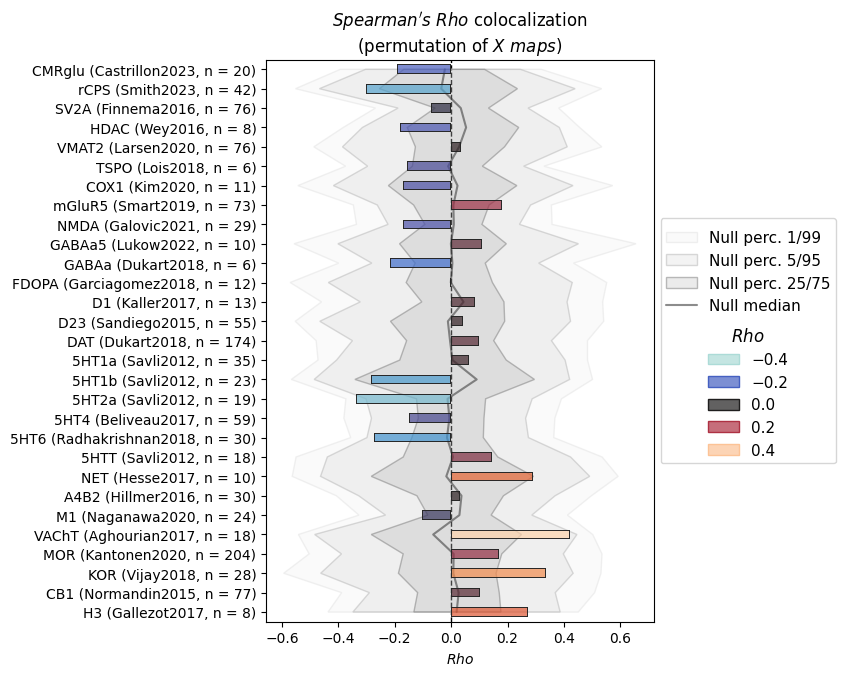

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x33ea13940>)

In [9]:
nsp.plot()

We can also visualize the input and reference maps as above, but here directly from NiSpace object:

INFO | 20/07/26 18:20:10 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 20/07/26 18:20:10 | nispace.api: Plotting Y data (Y_transform='False').


INFO | 20/07/26 18:20:10 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


WARNING | 20/07/26 18:20:10 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:20:10 | nispace.plotting: brainplot: threshold='auto' → 0.0017398296622559428


INFO | 20/07/26 18:20:10 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


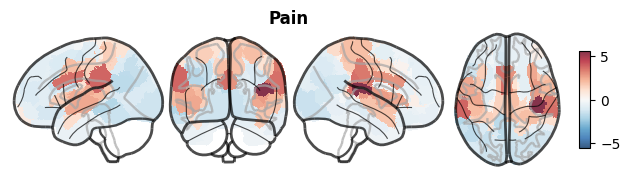

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [10]:
# the pain map
nsp.plot_brain(data="Y")

INFO | 20/07/26 18:20:13 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 20/07/26 18:20:13 | nispace.api: Plotting X data (X_reduction='False').


INFO | 20/07/26 18:20:13 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


WARNING | 20/07/26 18:20:13 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 20/07/26 18:20:13 | nispace.plotting: brainplot: threshold='auto' → 0.0001124086047639139


INFO | 20/07/26 18:20:13 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


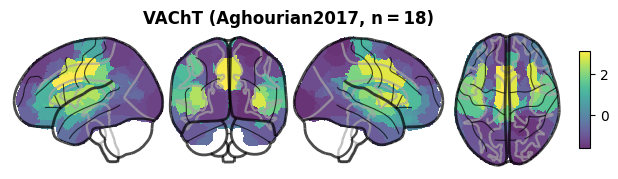

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [11]:
# the VAChT receptor map (strongest colocalization)
nsp.plot_brain(data="X", maps="VAChT", symmetric_cmap=False)

## Saving and loading

Analyses with 10,000 permutations or more take time to generate. We can serialize the entire NiSpace object — including the null distributions — to disk with `to_pickle()`, and load it back with `from_pickle()`.

We recommend the `.pkl.blosc` format: Blosc compression keeps file sizes manageable without the speed penalty of gzip. When running with many permutations but using a method that generates null maps fast (e.g., `"spin"` or `"moran"`), it sometimes makes sense to save without the null maps to spare storage space.

In [12]:
import os

# save, including the null distributions
nsp.to_pickle("intro02_nsp.pkl.blosc")
print(f"With nulls:    {os.path.getsize('intro02_nsp.pkl.blosc') / 1e6:.1f} MB")

# save without nulls — much smaller, but you lose the shading in plots
nsp.to_pickle("intro02_nsp_no_nulls.pkl.blosc", save_nulls=False)
print(f"Without nulls: {os.path.getsize('intro02_nsp_no_nulls.pkl.blosc') / 1e6:.1f} MB")

With nulls:    166.8 MB


Without nulls: 144.8 MB


In [13]:
# load it back
nsp_loaded = NiSpace.from_pickle("intro02_nsp.pkl.blosc")

import numpy as np
assert np.allclose(
    nsp.get_colocalizations().values,
    nsp_loaded.get_colocalizations().values
)
print("Loaded successfully — results are identical.")

INFO | 20/07/26 18:20:20 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


INFO | 20/07/26 18:20:20 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Loaded successfully — results are identical.


## Summary

The complete NiSpace workflow in six lines:

```python
nsp = NiSpace(x=reference_maps, y=input_map, parcellation="Yan200")
nsp.fit()                                          # parcellate + ingest
nsp.colocalize("spearman")                         # compute correlations
nsp.permute("maps", n_perm=10000, p_tails="upper") # permutation p-values
nsp.correct_p(mc_method=...)                       # multiple comparisons correction
nsp.plot()                                         # visualize
```

The next notebook covers [what datasets and parcellations are available, and how to bring in your own data](intro03_fetching_datasets.ipynb).

To explore which brain regions drive the colocalization results computed here, see the [Regional Diagnostics notebook](intro15_regional_diagnostics.ipynb).